# Fine-tuning U-Net architecture — modèles 2,5D (séquentiels)
Notebook dédié aux deux modèles qui exploitent la dépendance entre coupes échographiques
d'un même poisson (voir `SliceSequenceUNetDataset`) :
- CSA-Net
- xLSTM-UNet

In [1]:
import numpy as np
import torch
import torch.optim as optim
import pickle 
import time
import sys
import pandas as pd

from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des fonctions utilitaires
from utils.models_config import collate_fn_sequence, split_dataset, BCE_DiceLoss_ignore, dataset_to_dict
from utils.post_traitement import keep_largest_components

# Importation des datasets personnalisés pour U-Net : 2D et 2,5D
from utils.dataset_2_5D import SliceSequenceUNetDataset

# Importation des modèles U-Net personnalisés
from models.CSANet import CSANet
from models.xLSTMUNet import xLSTMUNet

/home/ldepiero/Debut/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random

# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Choix du modèle

In [ ]:
name = "csanet" # ou xlstm

### Importation et traitement des données

In [ ]:
# -------- 1. Importation des données --------
all_images_dir = "../data/images/cavite"  # Images
annotations_json = "../data/labels/COCO/cavite/annotations.json" # Fichier JSON COCO

# Importation du Data Frame avec les metadata
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# Formatage et regroupement des images et des annotations dans un dictionnaire pour faciliter l'accès aux données
# ignore_category_id : id COCO de la catégorie "ignore" si elle existe dans l'export (None sinon).
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, all_images_dir)

# Canal du masque sur lequel appliquer la zone "ignore" (uniquement la classe Gonade)
gonade_cat_id = next(cid for cid, name in categories.items() if name == "Gonade")
gonade_channel_idx = class_ids.index(gonade_cat_id)

### Division du jeu de données

In [4]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, all_images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, dim="2.5D")
test_dataset[0]["image"].shape

Nombre total d'images valides : 83
Échantillons train/val        : 69
Échantillons de test          : 14


torch.Size([4, 3, 512, 512])

## CSA-Net et xLSTM-UNet — dépendance entre coupes échographiques

Les architectures précédentes traitent chaque image indépendamment. Or les images d'un même poisson forment une **séquence de coupes échographiques ordonnées** (voir `position` / `position_ratio` dans les métadonnées), qui s'apparente à un volume 3D pseudo-continu.

Les deux modèles ci-dessous partagent le même principe :
- Chaque coupe de la séquence est encodée indépendamment par l'encodeur ResNet34 (poids partagés entre les coupes).
- Les features du **bottleneck** (la représentation la plus profonde) sont mélangées le long de la dimension des coupes `T`, pour propager le contexte entre coupes voisines.
- Chaque coupe est ensuite décodée indépendamment par le décodeur U-Net habituel (skip connections non mélangées).

Entrée attendue : `(B, T, C, H, W)` — un batch de `B` séquences de `T` coupes RGB `(C=3, H=512, W=512)`.
Sortie : `(B, T, num_classes, H, W)` — un masque multi-classes par coupe.

### Dataset séquentiel par poisson (`SliceSequenceUNetDataset`)

Regroupe les coupes de `RoboflowUNetDataset` par poisson (`id_poisson`) et les trie par
position (`position_ratio`, repli sur `position`), pour produire des séquences
`(T, C, H, W)` / `(T, num_classes, H, W)` consommables par `CSANet` / `xLSTMUNet`.

- Le chargement par coupe (décodage COCO, crop, resize, normalisation) n'est pas
  dupliqué : ce dataset instancie en interne un `RoboflowUNetDataset(is_train=False)`.
- Pas de padding : la longueur `T` varie selon le poisson (1 à 7 coupes dans les
  données actuelles) → chaque batch = un seul poisson (`batch_size=1`, via
  `collate_fn_sequence`).
- Augmentation appliquée au niveau de la séquence entière (`data_augmentation_sequence`),
  pas coupe par coupe, pour ne pas casser la correspondance spatiale entre coupes.

### Hyperparamètres du modèle et initialisation

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- Hyperparamètres ----
epochs = 200
nb_channels = 3
learning_rate = 1e-4

# ---- Fct de perte ----
# BCE_DiceLoss_ignore : identique à BCE_DiceLoss mais exclut les pixels marqués -100 (zones "ignore") du calcul de la BCE et du Dice.
loss_fn = BCE_DiceLoss_ignore(bce_weight=0.5, dice_weight=0.5) # Fct de perte combinée BCE + Dice Loss

# ---- Early stopping config ----
early_stopping_patience = 10  # nombre d'epochs sans amélioration avant arrêt
early_stopping_min_delta = 1e-3  # amélioration minimale considérée comme significative

# ---- Cross validation k-folds ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
X = np.array(cv_samples, dtype=object) # Les images

# Initialisation
fold_histories = {}
best_epochs = []

Utilisation de l'appareil: cuda


### Images selectionnées par batch

In [6]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X, cv_categories, groups_train)):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    val_names = [x["image_info"]["file_name"] for x in cv_samples[val_idx]]
    print(val_names)


--- DEBUT DU FOLD 1/5 ---
['0004576_10.50.21_356323_2019.jpg', '0004579_10.51.07_356323_2019.jpg', '0004586_12.06.43_356418_2019.jpg', '0004587_12.06.54_356418_2019.jpg', '0004588_12.07.07_356418_2019.jpg', '0004589_12.07.19_356418_2019.jpg', '0004647_11.15.45_356859_2019.jpg', '0004648_11.15.58_356859_2019.jpg', '0004649_11.16.08_356859_2019.jpg', '0007108_09.45.49_427184_2024.jpg', '0007109_09.45.54_427184_2024.jpg', '0007110_09.46.00_427184_2024.jpg', '0007111_09.46.06_427184_2024.jpg', '0007116_09.51.19_427193_2024.jpg']
--- DEBUT DU FOLD 2/5 ---
['0004657_11.29.44_356877_2019.jpg', '0004658_11.29.54_356877_2019.jpg', '0004664_11.58.29_356918_2019.jpg', '0004666_11.58.51_356918_2019.jpg', '0006939_10.23.25_426729_2024.jpg', '0006940_10.23.33_426729_2024.jpg', '0006941_10.23.42_426729_2024.jpg', '0006942_10.23.51_426729_2024.jpg', '0006954_11.06.31_426770_2024.jpg', '0006955_11.06.41_426770_2024.jpg', '0006956_11.06.49_426770_2024.jpg', '0007148_11.01.23_427276_2024.jpg', '0007149_1

### Entrainement et validation du modèle

In [ ]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X, cv_categories, groups_train)):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time() # Initialisation temps d'execution du fold

    # -------- 1. Création des jeux de données pour ce fold --------
    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]

    train_dataset = SliceSequenceUNetDataset(samples=train_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE,
                                             num_classes=num_classes, class_ids=class_ids, is_train = True,
                                             ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
    val_dataset = SliceSequenceUNetDataset(samples=val_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE,
                                           num_classes=num_classes, class_ids=class_ids, is_train=False,
                                           ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)

    # Générateur dédié au shuffle du train_loader : indépendant du générateur global
    # torch (donc de l'aléa consommé par l'initialisation du modèle), pour que l'ordre
    # des batchs soit identique quel que soit le modèle comparé.
    loader_g = torch.Generator()
    loader_g.manual_seed(SEED + fold)

    # batch_size=1 : chaque batch correspond à une séquence complète (un poisson), T
    # variant selon le poisson (1 à 7 coupes, pas de padding) -> collate_fn_sequence.
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn_sequence, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn_sequence)

    # Lookup catégorie/position/échelle par chemin d'image : SliceSequenceUNetDataset regroupe et
    # trie les coupes par poisson, donc l'ordre de sortie du val_loader ne correspond plus
    # à l'ordre de val_samples. On associe chaque coupe prédite à ses métadonnées via son
    # image_path (renvoyé par le dataset) plutôt que par position dans une liste.
    # L'échelle (colonne "echelle" de df) est propre à chaque image, contrairement à category/position
    # qui sont ici indexées par chemin pour la même raison.
    val_meta_by_path = {
        sample['image_path']: (
            sample['category'],
            int(sample['position']),
            float(sample['position_ratio']),
            df.loc[df["image_id"] == sample["image_info"]["file_name"].split("_")[0], "echelle"].values[0] / IMAGE_SIZE[1],
        )
        for sample in val_samples
    }

    # -------- 2. Réinitialisation complète du Modèle et Optimiseur --------
    # Reseed juste avant la création du modèle : rend l'initialisation des poids
    # (et le dropout éventuel) reproductible d'un run à l'autre pour un même modèle,
    # sans affecter l'augmentation ni l'ordre des batchs (découplés ci-dessus).
    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)

    # CSA-Net
    if name == "csanet":
        model = CSANet(num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet")
    elif name == "xlstm":
        model = xLSTMUNet(num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet", max_seq_len=8)

    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Optimiseur AdamW and une regularisation L2 (weight decay) pour éviter l'overfitting
    # Scheduler pour réduire le learning rate si la validation loss ne s'améliore pas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)


    # -------- 2. Initialisation par fold --------
    # Dictionnaires pour sauvegarder les résultats
    history = {'train_loss': [], 
               'val_loss': [], 
               'val_iou': [],
               'val_iou_all' : [],
               'val_surf_diff_cm2': [],
               'best_epoch_all_iou': [],
               'best_epoch_iou_gonade' : [],
               'best_epoch_categories': [],
               'best_epoch_ops': [],
               'best_epoch_ops_ratio': [],
               'best_epoch_diff_surf': []}
    
    
    best_val_loss = float('inf')
    best_epoch = -1
    early_stopping_counter = 0


    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # Epoch courante : utilisée par le dataset pour dériver un seed d'augmentation déterministe et identique entre modèles comparés.
        train_dataset.epoch = epoch
        val_dataset.epoch = epoch
        
        # -------------- 3. Training --------------
        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch['image'].to(device, non_blocking=True)          # (1, T, C, H, W)
            masks = batch['mask'].to(device, non_blocking=True).squeeze(0) # (T, num_classes, H, W)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images).squeeze(0) # (1,T,C,H,W) -> forward -> (1,T,num_classes,H,W) -> (T,num_classes,H,W)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            # Perte cumulée (pondérée par le nombre de coupes T de cette séquence)
            batch_size = masks.size(0)
            running_loss += loss.item() * batch_size
            running_count += batch_size

        # Calcul de la perte moyenne de l'epoch
        avg_train_loss = running_loss / running_count if running_count > 0 else 0.0

        # -------------- 4. Validation ----------------
        model.eval()
        val_loss = 0.0
        val_count = 0.0

        epoch_intersection_gonade = torch.tensor(0.0, device=device)
        epoch_union_gonade = torch.tensor(0.0, device=device)
        epoch_intersection_all = torch.tensor(0.0, device=device)
        epoch_union_all = torch.tensor(0.0, device=device)
        total_diff_surf_cm2 = torch.tensor(0.0, device=device)

        epoch_all_iou_tensors = []
        epoch_iou_gonade_tensors = []
        epoch_diff_surf_tensors = []
        epoch_categories = []
        epoch_ops = []
        epoch_ops_ratio = []

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, non_blocking=True)          # (1, T, C, H, W)
                masks = batch['mask'].to(device, non_blocking=True).squeeze(0) # (T, num_classes, H, W)

                outputs = model(images).squeeze(0) # (T, num_classes, H, W)
                loss = loss_fn(outputs, masks)

                # Cumul de la perte et du nombre d'échantillons (T coupes de cette séquence)
                batch_size = masks.size(0)
                val_loss += loss.item() * batch_size
                val_count += batch_size

                # --- Prédictions ---
                # valid_mask exclut les pixels marqués -100 (zones "ignore") : ni le vrai
                # masque ni la prédiction n'y contribuent, donc ils sont exclus de l'IoU/surface
                # exactement comme s'ils n'existaient pas (au lieu d'être comptés comme "pas de gonade").
                valid_mask = masks != -100
                probs = torch.sigmoid(outputs)
                true = (masks > 0.5) & valid_mask
                preds = (probs > 0.5) & valid_mask

                # --- Post-processing : garder uniquement la plus grande composante ---
                preds = keep_largest_components(preds) & valid_mask

                # --- Calcul de l'IoU ---
                intersection = (preds & true).float().sum((2, 3))
                union = (preds | true).float().sum((2, 3))   
                
                iou_per_img = intersection / (union + 1e-6)  
                iou_per_img[union==0] = 1.0
                iou_gonade = iou_per_img[:,1]

                epoch_iou_gonade_tensors.append(iou_gonade)
                epoch_all_iou_tensors.append(iou_per_img)
                
                # Cumul pour l'IoU Global de l'epoch
                epoch_intersection_gonade += intersection[:, 1].sum()
                epoch_union_gonade += union[:, 1].sum()
                epoch_intersection_all += intersection.sum()
                epoch_union_all += union.sum()

                # Échelle par coupe de cette séquence, dans l'ordre des coupes (même ordre que preds/true)
                image_paths = batch['image_path'][0]  # T chemins de cette séquence, dans l'ordre des coupes
                echelle_seq = torch.tensor(
                    [val_meta_by_path[p][3] for p in image_paths],
                    device=device, dtype=torch.float32
                ).view(-1, 1)

                #--- Calcul des surfaces en cm2 ---
                pred_surf_pixels = preds.float().sum((2, 3))
                true_surf_pixels = true.float().sum((2, 3))
                diff_surf_pixels = (true_surf_pixels - pred_surf_pixels).abs()
                diff_surf_cm2 = diff_surf_pixels * (echelle_seq ** 2)

                diff_surf_cm2_gonade = diff_surf_cm2[:,1] # Récupère les surfaces uniquement des gonades

                epoch_diff_surf_tensors.append(diff_surf_cm2_gonade)
                total_diff_surf_cm2 += diff_surf_cm2_gonade.sum()

                # --- Métadonnées (catégorie / position), une par coupe, même ordre que les prédictions ---
                for image_path in image_paths:
                    cat, op, op_ratio, _ = val_meta_by_path[image_path]
                    epoch_categories.append(cat)
                    epoch_ops.append(op)
                    epoch_ops_ratio.append(op_ratio)

        # Transfer sur le CPU en fin d'epoch
        epoch_iou_gonade = torch.cat(epoch_iou_gonade_tensors).cpu().tolist()
        epoch_all_iou = torch.cat(epoch_all_iou_tensors).cpu().tolist()
        epoch_diff_surf = torch.cat(epoch_diff_surf_tensors).cpu().tolist()

        # Fin de la validation de l'epoch
        avg_val_loss = val_loss / val_count
        mean_val_iou = (epoch_intersection_gonade / (epoch_union_gonade + 1e-6)).item()
        mean_val_iou_all = (epoch_intersection_all / (epoch_union_all + 1e-6)).item()
        mean_diff_cm2 = (total_diff_surf_cm2).item() / val_count

        scheduler.step(avg_val_loss) # Scheduler

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(mean_val_iou)
        history['val_iou_all'].append(mean_val_iou_all)
        history['val_surf_diff_cm2'].append(mean_diff_cm2)
        
        # Early stopping + sauvegarde
        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), f"unet_finetuned_2_5D_fold_{fold+1}_{name}.pth")
            early_stopping_counter = 0  # reset counter

            history['best_epoch_all_iou'] = epoch_all_iou
            history['best_epoch_iou_gonade'] = epoch_iou_gonade
            history['best_epoch_categories'] = epoch_categories
            history['best_epoch_ops'] = epoch_ops
            history['best_epoch_ops_ratio'] = epoch_ops_ratio
            history['best_epoch_diff_surf'] = epoch_diff_surf

        else:
            early_stopping_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch}/{epochs} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {epoch_time:.1f}s, lr : {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration (patience={early_stopping_patience}).")
            break
        
    # Résultats finaux
    print(f"Meilleur epoch (selon val_loss): {best_epoch} avec val_loss={best_val_loss:.4f}")
    print(f"Modèle sauvegardé sous unet_finetuned_2_5D_fold_{fold+1}.pth (dernier best)")
    
    # Sauvegarde du temps d'execution
    fold_total_time = time.time() - fold_start_time
    history['fold_time_seconds'] = fold_total_time
    
    fold_histories[f'fold_{fold+1}'] = history
    best_epochs.append(best_epoch)

--- DEBUT DU FOLD 1/5 ---
Epoch 1/200 — train_loss: 0.7186, val_loss: 0.7063, val_iou: 0.2648, time: 4.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 2/200 — train_loss: 0.6415, val_loss: 0.6459, val_iou: 0.4560, time: 3.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 3/200 — train_loss: 0.6126, val_loss: 0.6278, val_iou: 0.3913, time: 3.6s, lr : 1.00e-04, early_stopping: 0/10
Epoch 4/200 — train_loss: 0.5695, val_loss: 0.5781, val_iou: 0.5064, time: 3.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 5/200 — train_loss: 0.5536, val_loss: 0.5572, val_iou: 0.5234, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 6/200 — train_loss: 0.5294, val_loss: 0.5183, val_iou: 0.5925, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 7/200 — train_loss: 0.5016, val_loss: 0.4833, val_iou: 0.6880, time: 3.3s, lr : 1.00e-04, early_stopping: 0/10
Epoch 8/200 — train_loss: 0.4826, val_loss: 0.4780, val_iou: 0.6351, time: 3.3s, lr : 1.00e-04, early_stopping: 0/10
Epoch 9/200 — train_loss: 0.4670, val_

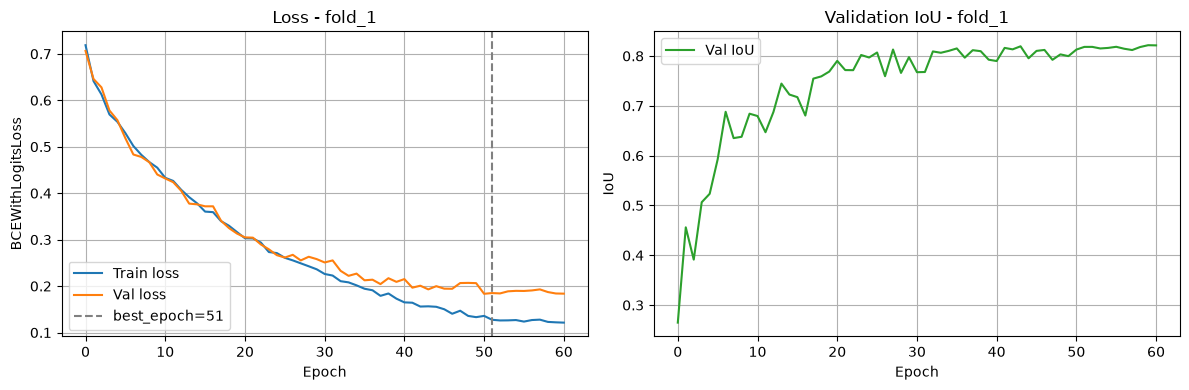

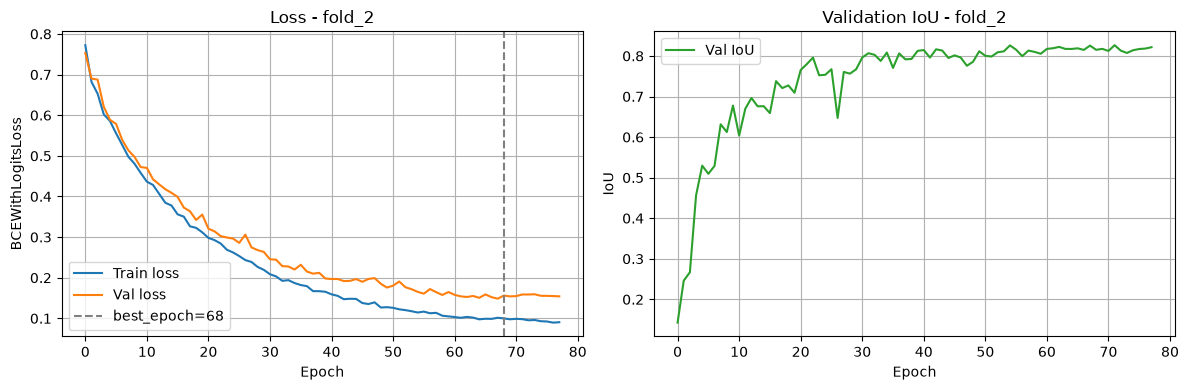

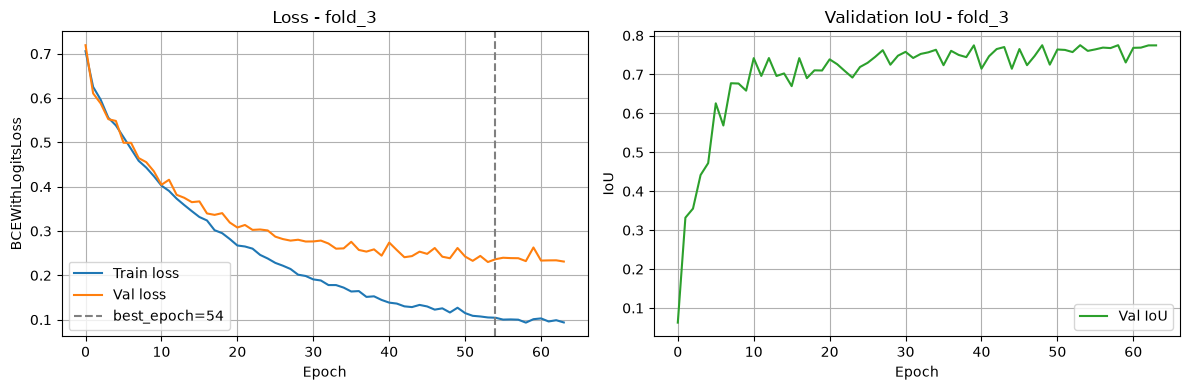

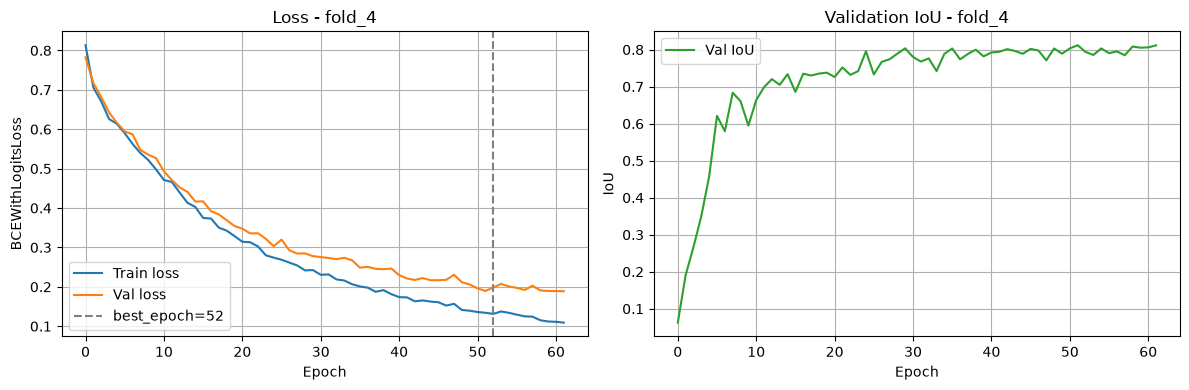

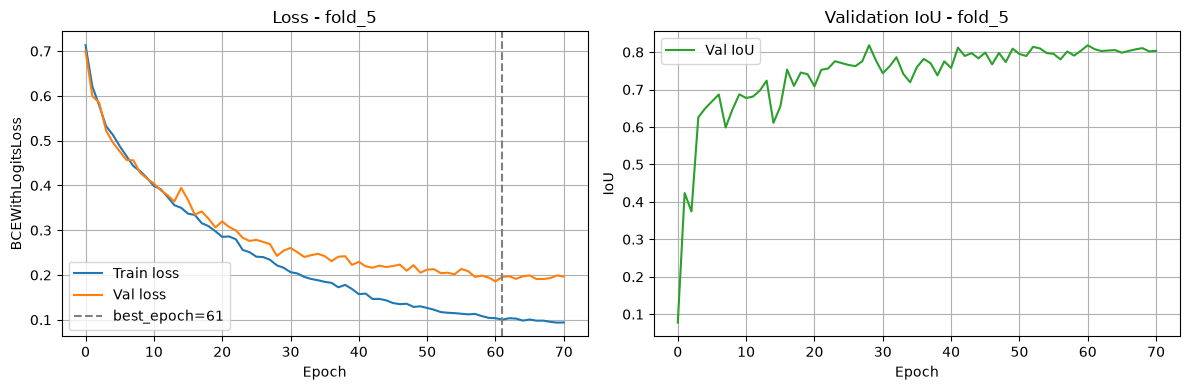

In [8]:
# Boucle sur les 5 folds de fold_histories
for i, (fold_name, history) in enumerate(fold_histories.items()):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Récupération de la meilleure époque pour le fold courant (si disponible)
    current_best_epoch = best_epochs[i] if 'best_epochs' in locals() and i < len(best_epochs) else 0

    # 1. Loss plot (train vs val)
    axs[0].plot(history['train_loss'], label='Train loss')
    axs[0].plot(history['val_loss'], label='Val loss')
    if current_best_epoch > 0:
        axs[0].axvline(current_best_epoch, color='gray', linestyle='--', label=f'best_epoch={current_best_epoch}')
    axs[0].set_title(f'Loss - {fold_name}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('BCEWithLogitsLoss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Val IoU plot
    iou_key = 'val_iou_all' if 'val_iou_all' in history else 'val_iou'
    axs[1].plot(history[iou_key], label='Val IoU', color='tab:green')
    axs[1].set_title(f'Validation IoU - {fold_name}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('IoU')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

### Sauvegarde des résultats

In [9]:
# A adapter selon le modèle actif ci-dessus (csanet / xltsm)
file_path = 'fold_histories_csanet.pkl'
results_path = 'results_csanet.pkl'

In [10]:
results_iou = [fold_histories['fold_1']["val_iou"][best_epochs[0]-1],
           fold_histories['fold_2']["val_iou"][best_epochs[1]-1],
            fold_histories['fold_3']["val_iou"][best_epochs[2]-1],
            fold_histories['fold_4']["val_iou"][best_epochs[3]-1], 
            fold_histories['fold_5']["val_iou"][best_epochs[4]-1],
            ]
results_iou

[0.7431893348693848,
 0.7117468118667603,
 0.6899278163909912,
 0.7712208032608032,
 0.7425353527069092]

In [11]:
# Sauvegarde de l'historique complet de tous les folds
with open(file_path, 'wb') as f:
    pickle.dump(fold_histories, f)

with open(results_path, 'wb') as f:
    pickle.dump(results_iou, f)